<a href="https://colab.research.google.com/github/Hkd225/yolov8-traffic-violation-detection/blob/main/yolov8_traffic_violation_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup selesai.
Working directory : /content
Output directory  : /content/traffic_violation_detection_yolo
Using Colab cache for faster access to the 'traffic-violation-detection-dataset' dataset.
Path dataset hasil download: /kaggle/input/traffic-violation-detection-dataset
Isi root download: ['labels', 'data.yaml', 'images']
Dataset YOLO ditemukan di: /kaggle/input/traffic-violation-detection-dataset

Isi data.yaml asli:
{
  "path": "/content/traffic_violation_v2",
  "train": "images/train",
  "val": "images/val",
  "nc": 23,
  "names": {
    "0": "person",
    "1": "car",
    "2": "truck",
    "3": "bus",
    "4": "motorcycle",
    "5": "red light",
    "6": "green light",
    "7": "stop sign",
    "8": "no entry",
    "9": "no overtaking",
    "10": "speed limit 20",
    "11": "speed limit 30",
    "12": "speed limit 40",
    "13": "speed limit 50",
    "14": "speed limit 60",
    "15": "speed limit 70",
    "16": "speed limit 80",
    "17": "speed limit 100",
    "18": "speed limit

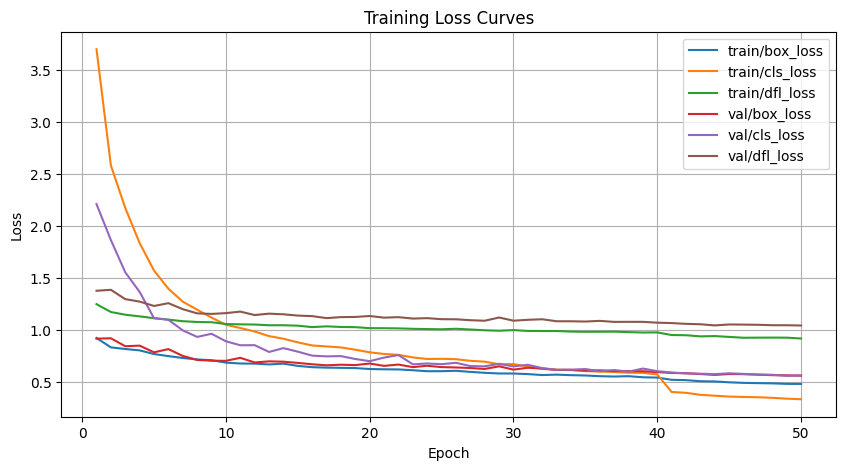

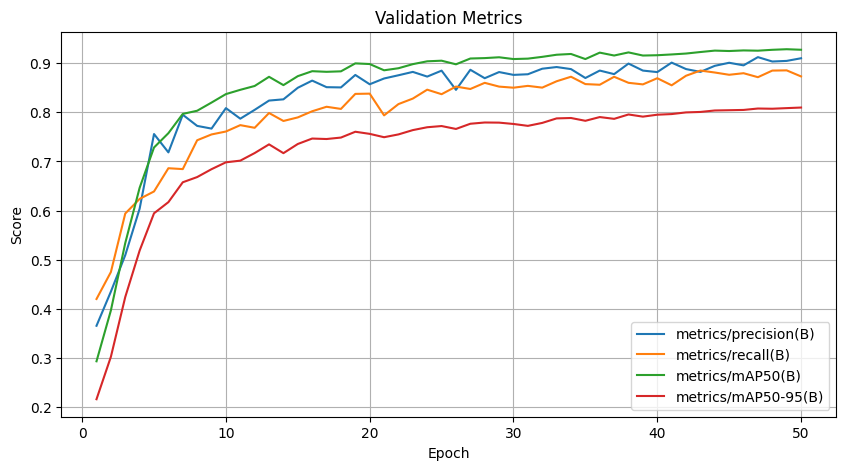


Menjalankan inferensi pada sample validation images...
Results saved to /content/traffic_violation_detection_yolo/predict_samples
Hasil inferensi sample disimpan di: /content/traffic_violation_detection_yolo/predict_samples


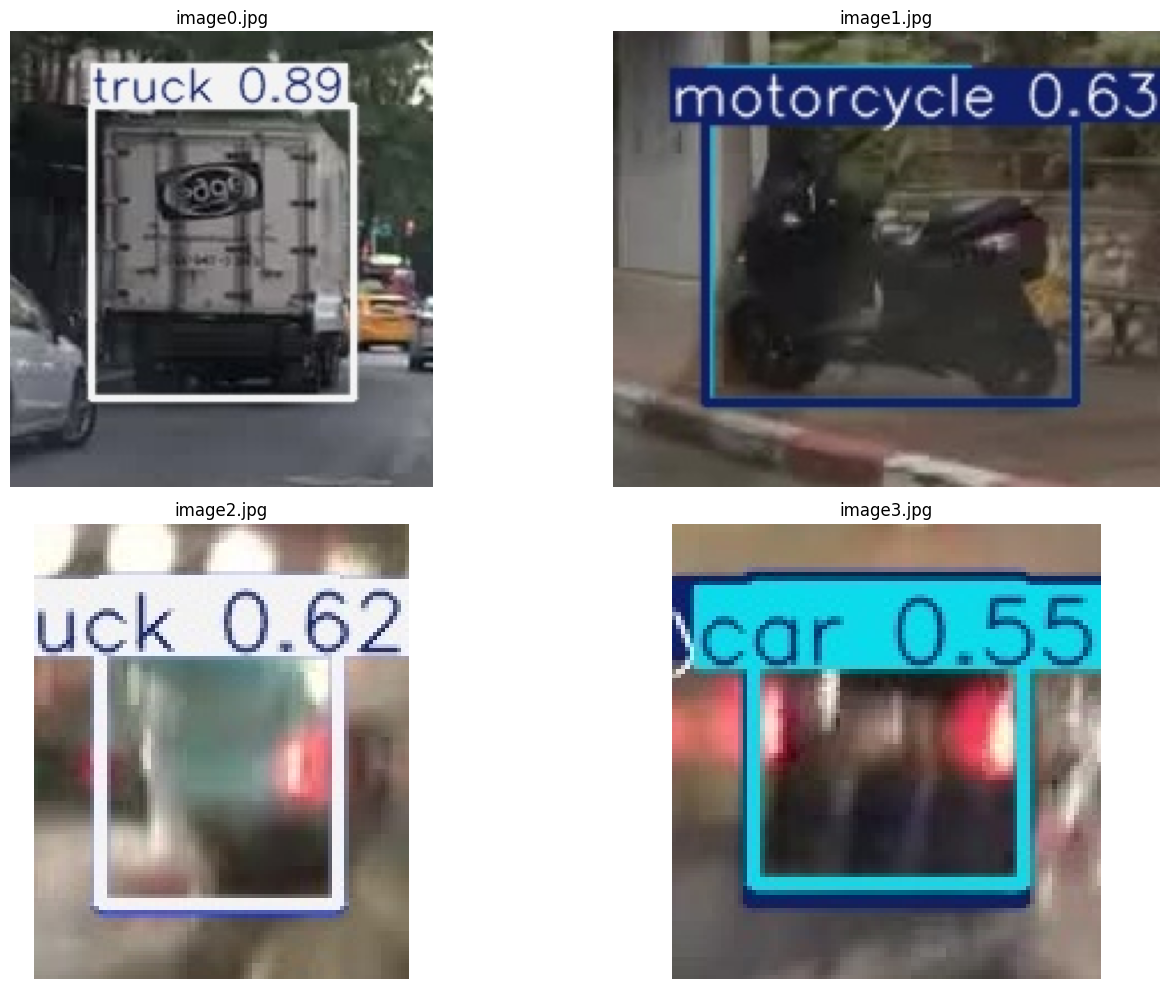


Upload gambar opsional untuk prediksi YOLO:


Saving download (26).jpg to download (26).jpg
File uploaded: download (26).jpg
Results saved to /content/traffic_violation_detection_yolo/predict_uploaded


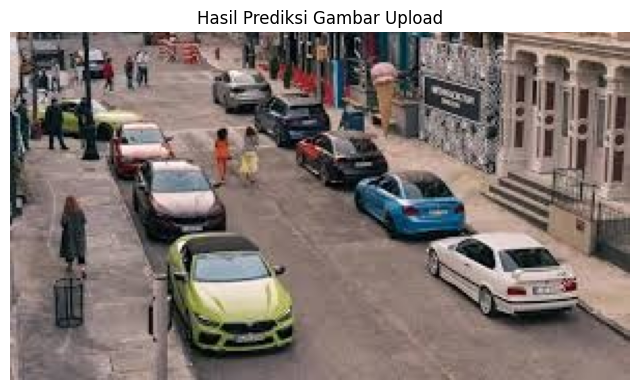


Export model ke format ONNX...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 27, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 247ms
Prepared 4 packages in 7.83s
Installed 4 packages in 248ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.88

requirements: AutoUpdate success ✅ 8.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimmi

SameFileError: '/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.onnx' and '/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.onnx' are the same file

In [2]:
!pip install -q ultralytics kagglehub pyyaml matplotlib seaborn scikit-learn pandas

import os
import shutil
import random
import zipfile
import yaml
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from ultralytics import YOLO
import kagglehub

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except:
    IN_COLAB = False

print("Setup selesai.")


SEED = 42
random.seed(SEED)
np.random.seed(SEED)



WORKING_DIR = os.getcwd()

PROJECT_TITLE = "traffic_violation_detection_yolo"
OUTPUT_DIR = os.path.join(WORKING_DIR, PROJECT_TITLE)
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
PREDICT_DIR = os.path.join(OUTPUT_DIR, "predictions")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
SAMPLE_DIR = os.path.join(OUTPUT_DIR, "samples")

for folder in [OUTPUT_DIR, MODEL_DIR, PREDICT_DIR, REPORT_DIR, SAMPLE_DIR]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

print("Working directory :", WORKING_DIR)
print("Output directory  :", OUTPUT_DIR)


#  DOWNLOAD DATA

dataset_path = kagglehub.dataset_download("guisahanes/traffic-violation-detection-dataset")
print("Path dataset hasil download:", dataset_path)
print("Isi root download:", os.listdir(dataset_path))

DATASET_DIR = dataset_path
DATA_YAML_ORIGINAL = os.path.join(DATASET_DIR, "data.yaml")

if not os.path.exists(DATA_YAML_ORIGINAL):
    raise FileNotFoundError(f"data.yaml tidak ditemukan di: {DATA_YAML_ORIGINAL}")

print("Dataset YOLO ditemukan di:", DATASET_DIR)


#  BACA data.yaml

with open(DATA_YAML_ORIGINAL, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

print("\nIsi data.yaml asli:")
print(json.dumps(data_config, indent=2, ensure_ascii=False))

# class names
class_names = data_config.get("names", [])
if isinstance(class_names, dict):
    class_names = [class_names[i] for i in sorted(class_names.keys())]

num_classes = len(class_names)

print("\nJumlah class:", num_classes)
print("Class names:")
for i, name in enumerate(class_names):
    print(f"{i:2d}. {name}")

# PATCH YAML
# Path asli salah -> ganti ke folder dataset yang benar
fixed_data_config = data_config.copy()
fixed_data_config["path"] = DATASET_DIR
fixed_data_config["train"] = "images/train"
fixed_data_config["val"] = "images/val"

FIXED_DATA_YAML = os.path.join(OUTPUT_DIR, "data_fixed.yaml")
with open(FIXED_DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(fixed_data_config, f, sort_keys=False, allow_unicode=True)

print("\nIsi data_fixed.yaml:")
print(json.dumps(fixed_data_config, indent=2, ensure_ascii=False))
print("Fixed YAML path:", FIXED_DATA_YAML)


# VALIDASI STRUKTUR

train_img_dir = os.path.join(DATASET_DIR, "images", "train")
val_img_dir = os.path.join(DATASET_DIR, "images", "val")
train_label_dir = os.path.join(DATASET_DIR, "labels", "train")
val_label_dir = os.path.join(DATASET_DIR, "labels", "val")

for p in [train_img_dir, val_img_dir, train_label_dir, val_label_dir]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Path tidak ditemukan: {p}")

def count_files(folder, exts=None):
    total = 0
    for f in os.listdir(folder):
        if exts is None:
            total += 1
        else:
            if f.lower().endswith(exts):
                total += 1
    return total

train_images_count = count_files(train_img_dir, (".jpg", ".jpeg", ".png", ".webp"))
val_images_count = count_files(val_img_dir, (".jpg", ".jpeg", ".png", ".webp"))
train_labels_count = count_files(train_label_dir, (".txt",))
val_labels_count = count_files(val_label_dir, (".txt",))

print("\nStatistik dataset:")
print("Train images :", train_images_count)
print("Val images   :", val_images_count)
print("Train labels :", train_labels_count)
print("Val labels   :", val_labels_count)


#  TRAIN

BASE_MODEL = "yolov8n.pt"
model = YOLO(BASE_MODEL)

print("\nMulai training YOLO...")
train_results = model.train(
    data=FIXED_DATA_YAML,   # pakai yaml hasil patch
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,               # ubah ke "cpu" kalau tidak ada GPU
    project=OUTPUT_DIR,
    name="train_run",
    exist_ok=True,
    pretrained=True,
    patience=10,
    seed=SEED,
    workers=2,
    verbose=True
)

print("\nTraining selesai.")


# 7. PATH MODEL

TRAIN_RUN_DIR = os.path.join(OUTPUT_DIR, "train_run")
BEST_MODEL_PATH = os.path.join(TRAIN_RUN_DIR, "weights", "best.pt")
LAST_MODEL_PATH = os.path.join(TRAIN_RUN_DIR, "weights", "last.pt")

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Model best.pt tidak ditemukan di: {BEST_MODEL_PATH}")

FINAL_MODEL_NAME = "traffic_violation_detection_yolo_best.pt"
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, FINAL_MODEL_NAME)
shutil.copy(BEST_MODEL_PATH, FINAL_MODEL_PATH)

print("Best model copied to:", FINAL_MODEL_PATH)


print("\nMenjalankan validasi model...")
best_model = YOLO(FINAL_MODEL_PATH)

metrics = best_model.val(
    data=FIXED_DATA_YAML,
    imgsz=640,
    split="val",
    save_json=False,
    plots=True
)

metric_summary = {
    "map50": float(metrics.box.map50),
    "map50_95": float(metrics.box.map),
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
}

print("\nHasil evaluasi:")
for k, v in metric_summary.items():
    print(f"{k:12s}: {v:.4f}")


RESULTS_CSV = os.path.join(TRAIN_RUN_DIR, "results.csv")
if os.path.exists(RESULTS_CSV):
    results_df = pd.read_csv(RESULTS_CSV)
    print("\nKolom results.csv:", list(results_df.columns))

    loss_cols = [c for c in results_df.columns if "loss" in c.lower()]
    if len(loss_cols) > 0:
        plt.figure(figsize=(10, 5))
        for col in loss_cols:
            plt.plot(results_df["epoch"], results_df[col], label=col)
        plt.title("Training Loss Curves")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    metric_cols = [c for c in results_df.columns if ("map" in c.lower() or "precision" in c.lower() or "recall" in c.lower())]
    if len(metric_cols) > 0:
        plt.figure(figsize=(10, 5))
        for col in metric_cols:
            if col != "epoch":
                plt.plot(results_df["epoch"], results_df[col], label=col)
        plt.title("Validation Metrics")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.legend()
        plt.grid(True)
        plt.show()


#  INFERENSI SAMPLE

val_images = sorted([
    os.path.join(val_img_dir, f) for f in os.listdir(val_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
])

sample_infer_images = val_images[:5]

print("\nMenjalankan inferensi pada sample validation images...")
best_model.predict(
    source=sample_infer_images,
    conf=0.25,
    save=True,
    project=OUTPUT_DIR,
    name="predict_samples",
    exist_ok=True,
    verbose=False
)

PREDICT_SAMPLE_DIR = os.path.join(OUTPUT_DIR, "predict_samples")
print("Hasil inferensi sample disimpan di:", PREDICT_SAMPLE_DIR)

pred_files = sorted([
    os.path.join(PREDICT_SAMPLE_DIR, f)
    for f in os.listdir(PREDICT_SAMPLE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

if len(pred_files) > 0:
    plt.figure(figsize=(15, 10))
    for i, img_path in enumerate(pred_files[:4]):
        img = plt.imread(img_path)
        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")
    plt.tight_layout()
    plt.show()


#  UPLOAD GAMBAR OPSIONAL

if IN_COLAB:
    print("\nUpload gambar opsional untuk prediksi YOLO:")
    uploaded = colab_files.upload()

    if len(uploaded) > 0:
        uploaded_img = next(iter(uploaded.keys()))
        print("File uploaded:", uploaded_img)

        best_model.predict(
            source=uploaded_img,
            conf=0.25,
            save=True,
            project=OUTPUT_DIR,
            name="predict_uploaded",
            exist_ok=True,
            verbose=False
        )

        uploaded_result_dir = os.path.join(OUTPUT_DIR, "predict_uploaded")
        uploaded_pred_files = sorted([
            os.path.join(uploaded_result_dir, f)
            for f in os.listdir(uploaded_result_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        if len(uploaded_pred_files) > 0:
            img = plt.imread(uploaded_pred_files[0])
            plt.figure(figsize=(8, 8))
            plt.imshow(img)
            plt.title("Hasil Prediksi Gambar Upload")
            plt.axis("off")
            plt.show()
    else:
        print("Tidak ada file di-upload.")



In [3]:

#EXPORT MODEL

print("\nExport model ke format ONNX...")
ONNX_MODEL_PATH = None

try:
    exported_path = best_model.export(format="onnx")
    if isinstance(exported_path, str) and os.path.exists(exported_path):
        ONNX_MODEL_PATH = exported_path
        print("ONNX model:", ONNX_MODEL_PATH)
except Exception as e:
    print("Export ONNX gagal:", str(e))


Export model ke format ONNX...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 27, 8400) (5.9 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.88...
ONNX: export success ✅ 1.7s, saved as '/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.onnx' (11.7 MB)

Export complete (2.8s)
Results saved to /content/traffic_violation_detection_yolo/models
Predict:         yolo predict task=detect model=/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.onnx imgsz=640 data=/content/traffic_violation_detection_yolo/data_fixed.yaml  

Label file disimpan di: /content/traffic_violation_detection_yolo/models/traffic_violation_labels.txt
Training config disimpan di: /content/traffic_violation_detection_yolo/reports/traffic_violation_training_config.json
README disimpan di: /content/traffic_violation_detection_yolo/README.md
requirements.txt disimpan di: /content/traffic_violation_detection_yolo/requirements.txt

Struktur folder output:
traffic_violation_detection_yolo/
    README.md
    data_fixed.yaml
    requirements.txt
    predict_samples/
        image0.jpg
        image1.jpg
        image2.jpg
        image3.jpg
        image4.jpg
    predict_reloaded_model/
        bdd_b1ceb32e-a106591d_crop0_crop0.jpg
    predictions/
    samples/
    train_run/
        BoxF1_curve.png
        BoxPR_curve.png
        BoxP_curve.png
        BoxR_curve.png
        args.yaml
        confusion_matrix.png
        confusion_matrix_normalized.png
        labels.jpg
        results.csv
        results.png
        train_batch0.jpg
     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== UJI LOAD MODEL ULANG ===
Model berhasil di-load ulang dari: /content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.pt
Uji inferensi ulang pada: /kaggle/input/traffic-violation-detection-dataset/images/val/bdd_b1ceb32e-a106591d_crop0_crop0.jpg
Results saved to /content/traffic_violation_detection_yolo/predict_reloaded_model


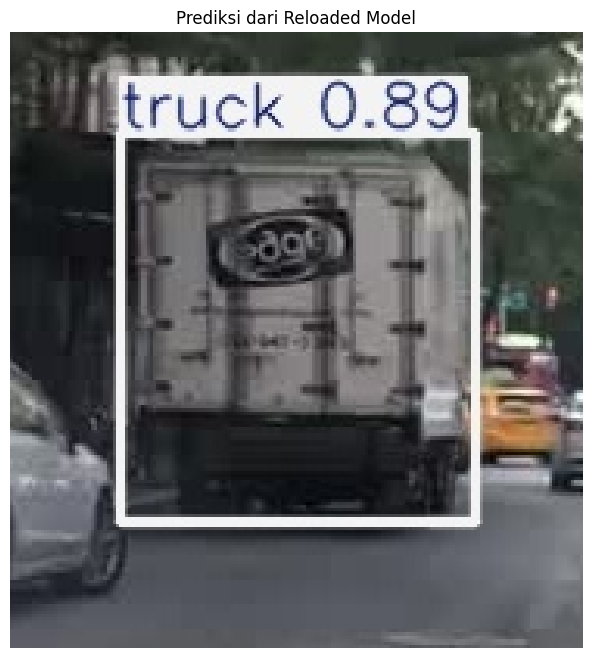


Selesai.


In [17]:

# SIMPAN LABEL DAN KONFIGURASI

LABEL_PATH = os.path.join(MODEL_DIR, "traffic_violation_labels.txt")
with open(LABEL_PATH, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

training_config = {
    "project_title": PROJECT_TITLE,
    "dataset": "guisahanes/traffic-violation-detection-dataset",
    "dataset_dir": DATASET_DIR,
    "original_data_yaml": DATA_YAML_ORIGINAL,
    "fixed_data_yaml": FIXED_DATA_YAML,
    "base_model": BASE_MODEL,
    "final_model_name": FINAL_MODEL_NAME,
    "final_model_path": FINAL_MODEL_PATH,
    "onnx_model_path": ONNX_MODEL_PATH,
    "num_classes": num_classes,
    "class_names": class_names,
    "train_images": train_images_count,
    "val_images": val_images_count,
    "epochs": 50,
    "imgsz": 640,
    "batch": 16,
    "seed": SEED,
    "metrics": metric_summary
}

TRAINING_CONFIG_PATH = os.path.join(REPORT_DIR, "traffic_violation_training_config.json")
with open(TRAINING_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(training_config, f, indent=2, ensure_ascii=False)

print("Label file disimpan di:", LABEL_PATH)
print("Training config disimpan di:", TRAINING_CONFIG_PATH)


README_PATH = os.path.join(OUTPUT_DIR, "README.md")
readme_content = f"""# Traffic Violation Detection YOLO

## Dataset
guisahanes/traffic-violation-detection-dataset

## Base Model
{BASE_MODEL}

## Final Model
- models/traffic_violation_detection_yolo_best.pt

## Exported Model
- models/traffic_violation_detection_yolo_best.onnx

## Number of Classes
{num_classes}

## Class Names
{", ".join(class_names)}

## Metrics
- mAP50     : {metric_summary['map50']:.4f}
- mAP50-95  : {metric_summary['map50_95']:.4f}
- Precision : {metric_summary['precision']:.4f}
- Recall    : {metric_summary['recall']:.4f}
"""

with open(README_PATH, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README disimpan di:", README_PATH)


REQUIREMENTS_PATH = os.path.join(OUTPUT_DIR, "requirements.txt")
requirements_content = """ultralytics
kagglehub
pyyaml
matplotlib
pandas
numpy
"""

with open(REQUIREMENTS_PATH, "w", encoding="utf-8") as f:
    f.write(requirements_content)

print("requirements.txt disimpan di:", REQUIREMENTS_PATH)


print("\nStruktur folder output:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in sorted(files):
        print(f"{subindent}{file}")


#  ZIP OUTPUT

ZIP_BASE = os.path.join(WORKING_DIR, "traffic_violation_detection_yolo_results")
ZIP_PATH = shutil.make_archive(ZIP_BASE, "zip", OUTPUT_DIR)

print("\nZIP berhasil dibuat di:", ZIP_PATH)

if IN_COLAB:
    colab_files.download(ZIP_PATH)


#  LOAD MODEL ULANG UNTUK UJI INFERENSI

print("\n=== UJI LOAD MODEL ULANG ===")
reloaded_model = YOLO(FINAL_MODEL_PATH)
print("Model berhasil di-load ulang dari:", FINAL_MODEL_PATH)

if len(val_images) > 0:
    test_img_path = val_images[0]
    print("Uji inferensi ulang pada:", test_img_path)

    reloaded_model.predict(
        source=test_img_path,
        conf=0.25,
        save=True,
        project=OUTPUT_DIR,
        name="predict_reloaded_model",
        exist_ok=True,
        verbose=False
    )

    reload_pred_dir = os.path.join(OUTPUT_DIR, "predict_reloaded_model")
    reload_pred_files = sorted([
        os.path.join(reload_pred_dir, f)
        for f in os.listdir(reload_pred_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    if len(reload_pred_files) > 0:
        img = plt.imread(reload_pred_files[0])
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title("Prediksi dari Reloaded Model")
        plt.axis("off")
        plt.show()

print("\nSelesai.")

Upload gambar:


Saving download (27).jpg to download (27) (1).jpg
File uploaded: download (27) (1).jpg
Results saved to /content/traffic_violation_detection_yolo/predict_compare


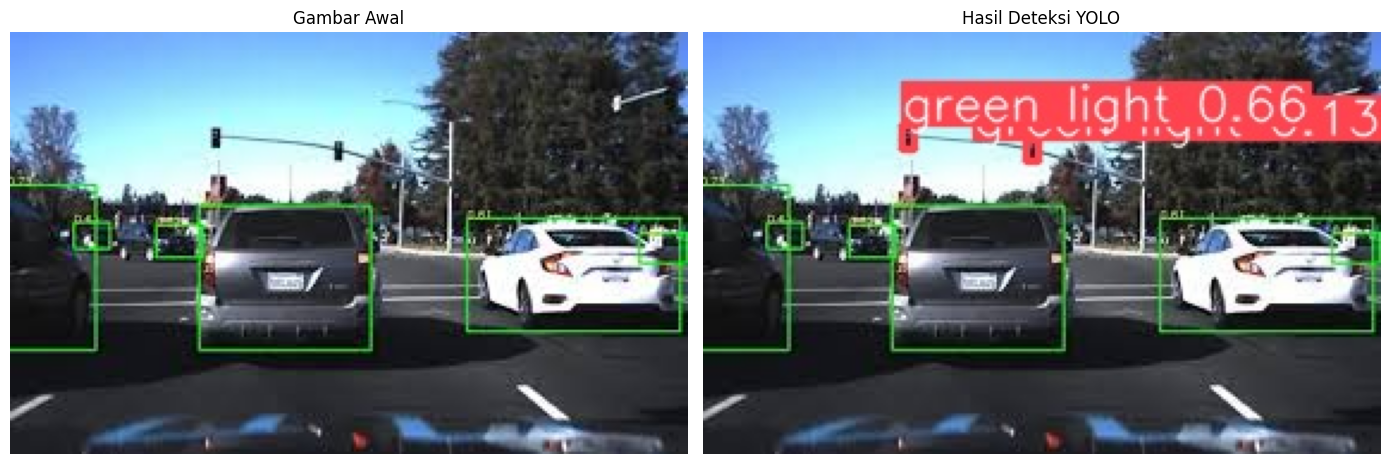


Objek terdeteksi:
1. green light | conf=0.6619
2. green light | conf=0.1292


In [15]:
from google.colab import files as colab_files
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import os

MODEL_PATH = "/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.pt"
model = YOLO(MODEL_PATH)

print("Upload gambar:")
uploaded = colab_files.upload()

if len(uploaded) == 0:
    print("Tidak ada file yang di-upload.")
else:
    img_path = next(iter(uploaded.keys()))
    print("File uploaded:", img_path)

    results = model.predict(
        source=img_path,
        imgsz=1280,
        conf=0.05,
        iou=0.45,
        augment=True,
        save=True,
        project="/content/traffic_violation_detection_yolo",
        name="predict_compare",
        exist_ok=True,
        verbose=False
    )

    result_img_path = os.path.join(
        "/content/traffic_violation_detection_yolo/predict_compare",
        os.path.basename(img_path)
    )

    # tampilkan gambar awal dan hasil
    original = Image.open(img_path).convert("RGB")
    detected = Image.open(result_img_path).convert("RGB")

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Gambar Awal")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(detected)
    plt.title("Hasil Deteksi YOLO")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # tampilkan daftar deteksi
    print("\nObjek terdeteksi:")
    boxes = results[0].boxes
    if boxes is not None and len(boxes) > 0:
        for i, box in enumerate(boxes):
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            print(f"{i+1}. {model.names[cls_id]} | conf={conf:.4f}")
    else:
        print("Tidak ada objek terdeteksi.")

Upload gambar:


Saving download (28).jpg to download (28) (2).jpg
File uploaded: download (28) (2).jpg

Deteksi full image:
Tidak ada objek terdeteksi pada full image.

Deteksi crop image:
1. car | conf=0.3351


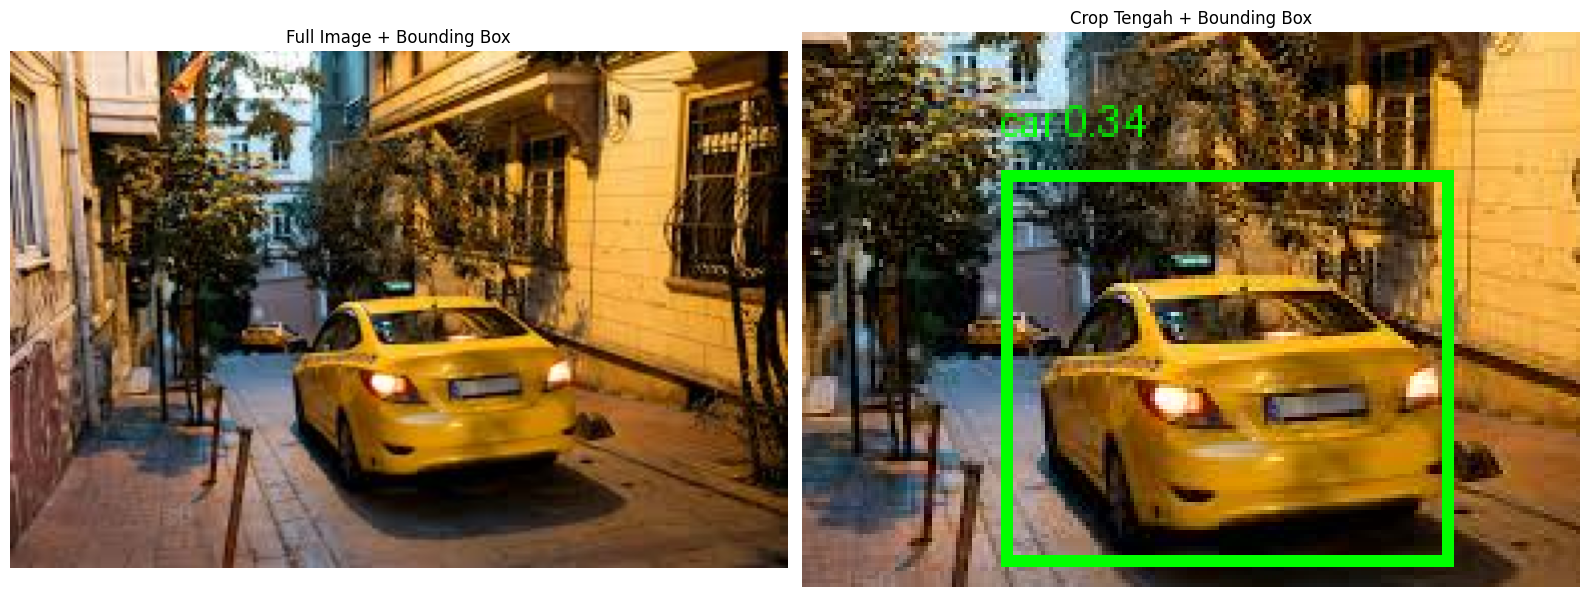

In [16]:
from google.colab import files as colab_files
from ultralytics import YOLO
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import os

MODEL_PATH = "/content/traffic_violation_detection_yolo/models/traffic_violation_detection_yolo_best.pt"
model = YOLO(MODEL_PATH)

print("Upload gambar:")
uploaded = colab_files.upload()

if len(uploaded) == 0:
    print("Tidak ada file yang di-upload.")
else:
    img_path = next(iter(uploaded.keys()))
    print("File uploaded:", img_path)

    # =========================
    # 1. Prediksi full image
    # =========================
    full_results = model.predict(
        source=img_path,
        imgsz=1280,
        conf=0.03,
        iou=0.45,
        augment=True,
        save=False,
        verbose=False
    )

    print("\nDeteksi full image:")
    if full_results[0].boxes is not None and len(full_results[0].boxes) > 0:
        for i, box in enumerate(full_results[0].boxes):
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            print(f"{i+1}. {model.names[cls_id]} | conf={conf:.4f}")
    else:
        print("Tidak ada objek terdeteksi pada full image.")

    # =========================
    # 2. Crop tengah gambar
    # =========================
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    left = int(w * 0.15)
    top = int(h * 0.15)
    right = int(w * 0.85)
    bottom = int(h * 0.90)

    cropped = img.crop((left, top, right, bottom))

    crop_results = model.predict(
        source=cropped,
        imgsz=1280,
        conf=0.03,
        iou=0.45,
        augment=True,
        save=False,
        verbose=False
    )

    print("\nDeteksi crop image:")
    if crop_results[0].boxes is not None and len(crop_results[0].boxes) > 0:
        for i, box in enumerate(crop_results[0].boxes):
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            print(f"{i+1}. {model.names[cls_id]} | conf={conf:.4f}")
    else:
        print("Tidak ada objek terdeteksi pada crop image.")

    # =========================
    # 3. Gambar bounding box full image
    # =========================
    full_annotated = img.copy()
    draw_full = ImageDraw.Draw(full_annotated)

    boxes = full_results[0].boxes
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            label = f"{model.names[cls_id]} {conf:.2f}"

            draw_full.rectangle([x1, y1, x2, y2], outline="red", width=3)
            draw_full.text((x1, max(0, y1 - 18)), label, fill="red")

    # =========================
    # 4. Gambar bounding box crop image
    # =========================
    crop_annotated = cropped.copy()
    draw_crop = ImageDraw.Draw(crop_annotated)

    boxes = crop_results[0].boxes
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            label = f"{model.names[cls_id]} {conf:.2f}"

            draw_crop.rectangle([x1, y1, x2, y2], outline="lime", width=3)
            draw_crop.text((x1, max(0, y1 - 18)), label, fill="lime")

    # =========================
    # 5. Tampilkan hasil
    # =========================
    plt.figure(figsize=(16, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(full_annotated)
    plt.title("Full Image + Bounding Box")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(crop_annotated)
    plt.title("Crop Tengah + Bounding Box")
    plt.axis("off")

    plt.tight_layout()
    plt.show()